<div>
Olá, Adelia!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. Essa versão do seu trabalho ficou muito boa! Espero que as sugestões sejam relevantes para projetos futuros. Como sugestão geral, considere organizar o seu notebook de forma a refletir a descrição do projeto. 
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# Projeto 9 - Teste A/B para Departamento de Marketing

## Etapa 1 - Extração e tratamento dos dados

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import Math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hypotheses = pd.read_csv(
    '/datasets/hypotheses_us.csv',
    sep=';'
)

In [3]:
print(hypotheses.info())
print('----------------------')
print(hypotheses.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None
----------------------
                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and 

In [4]:
orders = pd.read_csv(
    '/datasets/orders_us.csv',
    dtype={'group': 'category'},
     parse_dates=['date']
)

In [5]:
print(orders.info())
print('----------------------')
print(orders.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 38.8 KB
None
----------------------
   transactionId   visitorId       date  revenue group
0     3667963787  3312258926 2019-08-15     30.4     B
1     2804400009  3642806036 2019-08-15     15.2     B
2     2961555356  4069496402 2019-08-15     10.2     A
3     3797467345  1196621759 2019-08-15    155.1     B
4     2282983706  2322279887 2019-08-15     40.5     B
5      182168103   935554773 2019-08-15     35.0     B
6      398296753  2900797465 2019-08-15  

In [6]:
visits = pd.read_csv(
    '/datasets/visits_us.csv',
    dtype={'group': 'category'},
     parse_dates=['date']
)

In [7]:
print(visits.info())
print('----------------------')
print(visits.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     category      
 2   visits  62 non-null     int64         
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 1.2 KB
None
----------------------
        date group  visits
0 2019-08-01     A     719
1 2019-08-02     A     619
2 2019-08-03     A     507
3 2019-08-04     A     717
4 2019-08-05     A     756
5 2019-08-06     A     667
6 2019-08-07     A     644
7 2019-08-08     A     610
8 2019-08-09     A     617
9 2019-08-10     A     406


In [8]:
def to_snake_case(name):
    name = name.replace(' ', '')
    name = name.replace('Id', '_id')
    name = name.lower()
    return name

hypotheses.columns = [to_snake_case(col) for col in hypotheses.columns]
visits.columns = [to_snake_case(col) for col in visits.columns]
orders.columns = [to_snake_case(col) for col in orders.columns]

print(hypotheses.info())
print(visits.info())
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     category      
 2   visits  62 non-null     int64         
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 1.2 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  

1. Foi realizada a importação das bibliotecas a serem usadas neste projeto.
2. Foram gerados 3 DataFrames, um para cada arquivo, chamados *hypotheses*, *orders* e *visits*, os quais contêm os dados brutos a serem trabalhados.
3. Foram utilizados os parâmetros *sep*, *dtype* e *parse_dates* para que os dfs já viessem com as formatações adequadas.
4. Foram utilizados os métodos .info() e .head() para realizar a análise inicial dos dados.
5. Foi criada uma função para padronizar o nome das colunas com *snake_case*.

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente
- O import das bibliotecas foi feito de forma correta e em uma célula separada
- Como sugestão, você poderia usar o método `describe()` aqui também para exibir as estatísticas descritivas do conjunto de dados

</div>

## Etapa 2 - Priorizando Hipóteses

### 1. Aplicar o framework ICE para priorizar hipóteses.

#### $ICE = \frac{Impact \times Confidence}{Effort}$

In [9]:
hypotheses['ICE'] = (
    hypotheses['impact']
    * hypotheses['confidence']
    / hypotheses['effort']
)

print(hypotheses[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))

                                          hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


### 2. Aplicar o framework RICE para priorizar hipóteses.

#### $ICE = \frac{Reach \times Impact \times Confidence}{Effort}$

In [10]:
hypotheses['RICE'] = (
    hypotheses['reach']
    * hypotheses['impact']
    * hypotheses['confidence']
    / hypotheses['effort']
)

print(hypotheses[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

                                          hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


In [11]:
print(hypotheses.head(10))

                                          hypothesis  reach  impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on ...      5       3   
7  Add a subscription form to all the main pages....     10       7   
8  Launch a promotion that gives users discounts ...      1       9   

   confidence  effort        ICE   RICE  
0           8       6  13.333333   40.0  
1           4      10   2.000000    4.0  
2           7       3   7.000000   56.0  
3           3       8   1.125000    9.0  
4           1       1   1.000000    3.0  
5           2       3   1.333333    4

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os indicadores `ICE` e `RICE` foram calculados corretamente para estimar o impacto de hipóteses. 
- As hipóteses foram ordenadas corretamente pelos scores criados!
</div>

### 3. Mostre como a priorização de hipóteses muda quando você usa RICE em vez de ICE.

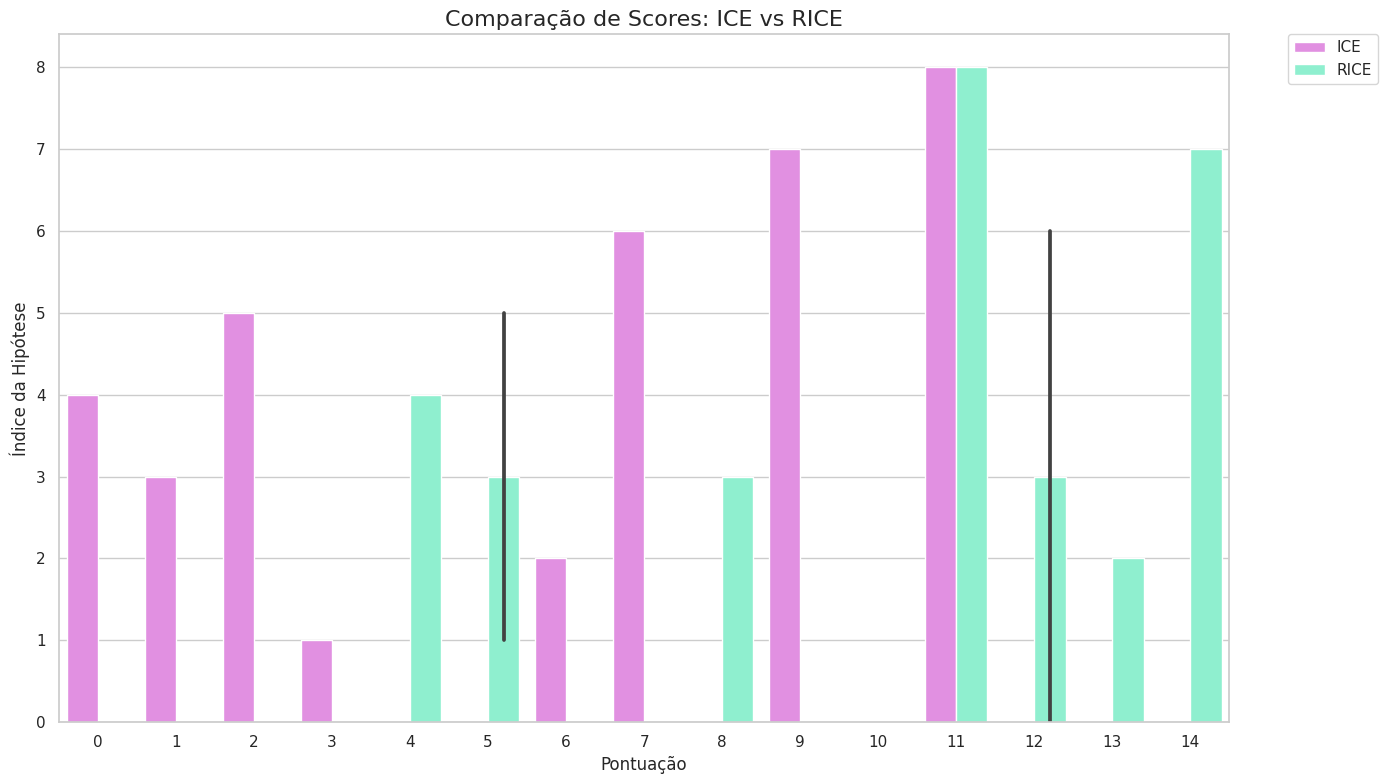

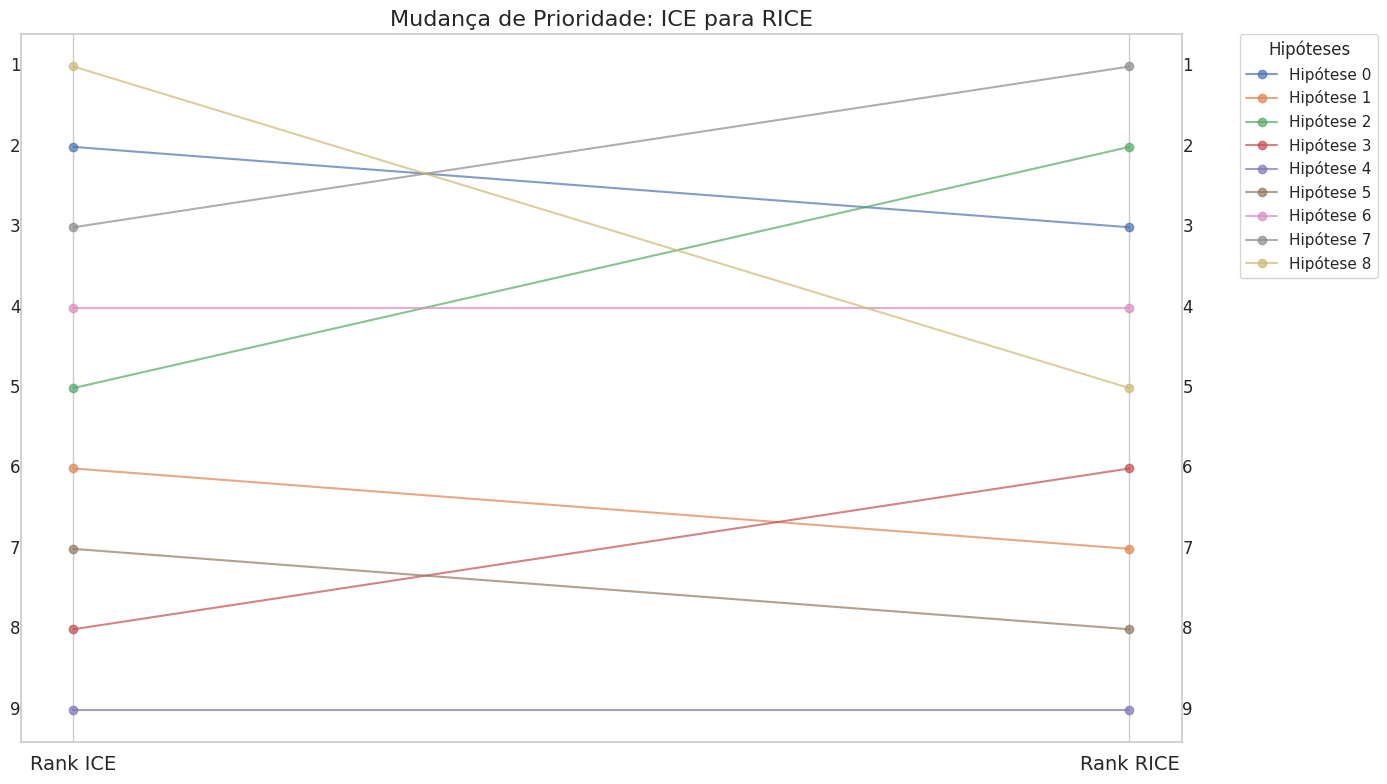

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [14, 8]
plt.rcParams["font.family"] = "sans-serif"

fig, ax1 = plt.subplots(figsize=(14, 8))
df_plot = hypotheses.reset_index().rename(columns={'index': 'Hypothesis_Index'})
df_melted = df_plot.melt(
    id_vars='Hypothesis_Index', 
    value_vars=['ICE', 'RICE'], 
    var_name='Framework', 
    value_name='Score'
)

sns.barplot(
    data=df_melted, 
    y='Hypothesis_Index', 
    x='Score', 
    hue='Framework', 
    ax=ax1, 
    palette=['violet', 'aquamarine']
)
ax1.set_title('Comparação de Scores: ICE vs RICE', fontsize=16)
ax1.set_ylabel('Índice da Hipótese', fontsize=12)
ax1.set_xlabel('Pontuação', fontsize=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}' if x % 1 != 0 else f'{int(x)}'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()
plt.close()

hypotheses['rank_ICE'] = hypotheses['ICE'].rank(ascending=False, method='first')
hypotheses['rank_RICE'] = hypotheses['RICE'].rank(ascending=False, method='first')

plt.figure(figsize=(14, 8))
for idx, row in hypotheses.iterrows():
    label_text = f'Hipótese {idx}'
    if 'hypothesis' in hypotheses.columns:
        label_text = f'Hipótese {idx}'

    plt.plot(
        [0, 1], 
        [row['rank_ICE'], row['rank_RICE']], 
        marker='o',
        label=label_text,
        alpha=0.7
    )
    plt.text(-0.05, row['rank_ICE'], f"{int(row['rank_ICE'])}", ha='right', va='center')
    plt.text(1.05, row['rank_RICE'], f"{int(row['rank_RICE'])}", ha='left', va='center')

plt.xticks([0, 1], ['Rank ICE', 'Rank RICE'], fontsize=14)
plt.yticks([])
plt.gca().invert_yaxis()
plt.title('Mudança de Prioridade: ICE para RICE', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Hipóteses')
plt.tight_layout()
plt.show()
plt.close()


1. Foram incluídas do df *hypotheses* as colunas **ICE** e **RICE** e foi definida a ordem de prioridade de cada framework.
2. Foi criado um gráfico de barras com o objetivo de comparar as pontuações absolutas desses frameworks para cada hipótese, utilizando o índice original para manter a rastreabilidade.
3. Foi elaborado um gráfico de inclinação para evidenciar as mudanças relativas na ordem de prioridade (ranking) ao transitar do **ICE** para o **RICE**.

O primeiro gráfico permite visualizar a magnitude do impacto que o fator "Alcance" (Reach) exerce sobre a pontuação final de cada experimento. Já o segundo torna explícito quais hipóteses ganharam relevância estratégica e quais perderam posições quando o volume de usuários afetados passou a ser considerado. 

Entende-se, portanto, que as prioridades do **ICE** — onde uma hipótese de alto impacto para um grupo restrito pode ser a número 1 — divergem do **RICE**, no qual as hipóteses que atingem uma base maior de usuários tendem a assumir o topo. 
Isso garante que o esforço seja direcionado para onde há maior potencial de escala e retorno sobre o investimento, devido ao acréscimo do alcance.

# Etapa 3 - Análise de teste A/B

### 1. Faça um gráfico da receita acumulada por grupo. 


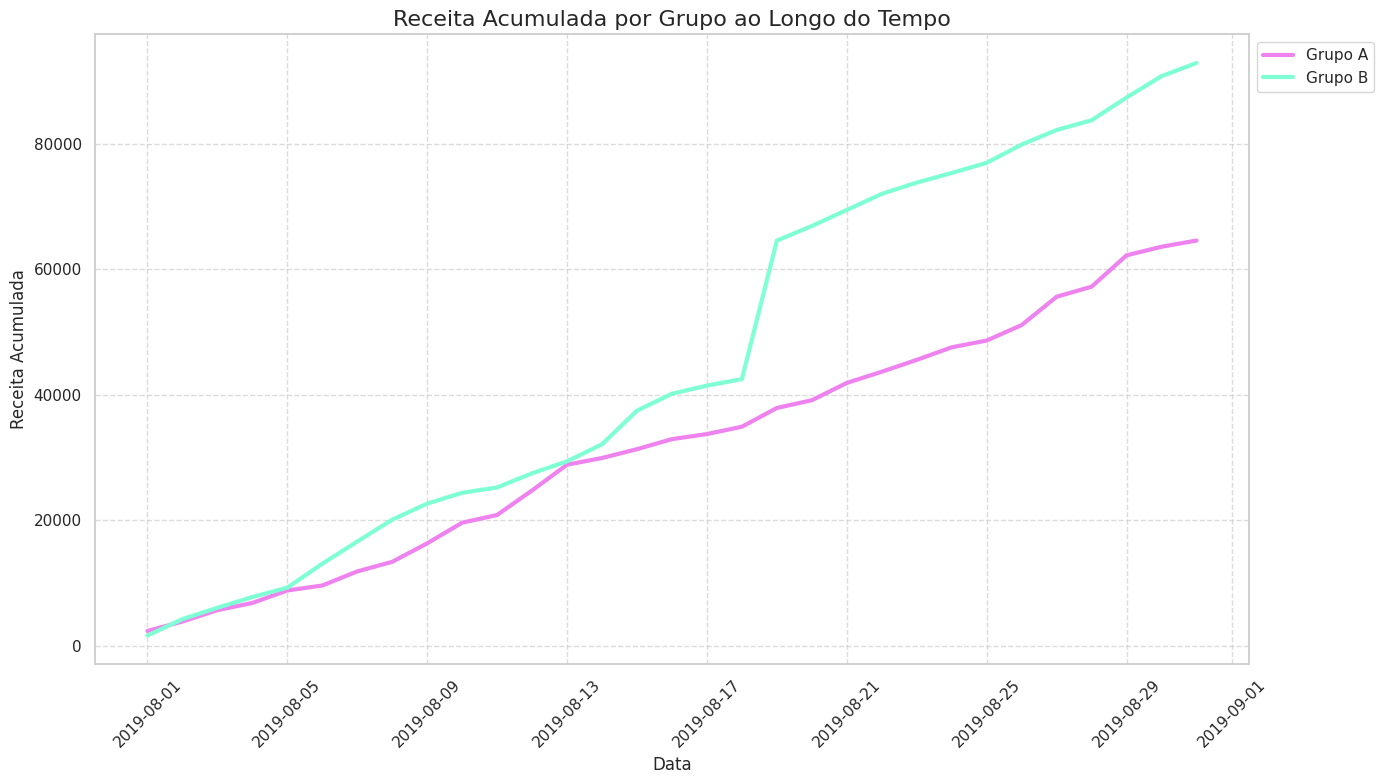

In [13]:
orders['date'] = pd.to_datetime(orders['date'])
datesGroups = orders[['date', 'group']].drop_duplicates()

ordersAggregated = datesGroups.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], 
            orders['group'] == x['group']
        )
    ].agg({
        'date': 'max',
        'group': lambda g: g.iloc[0],
        'transaction_id': 'nunique',
        'visitor_id': 'nunique',
        'revenue': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

cumulativeRevenueA = ordersAggregated[ordersAggregated['group'] == 'A'][['date', 'revenue', 'transaction_id']]
cumulativeRevenueB = ordersAggregated[ordersAggregated['group'] == 'B'][['date', 'revenue', 'transaction_id']]

plt.figure(figsize=(14, 8))

plt.plot(
    cumulativeRevenueA['date'], 
    cumulativeRevenueA['revenue'], 
    label='Grupo A', 
    color='violet', 
    linewidth=3
)
plt.plot(
    cumulativeRevenueB['date'], 
    cumulativeRevenueB['revenue'], 
    label='Grupo B', 
    color='aquamarine', 
    linewidth=3
)

plt.title('Receita Acumulada por Grupo ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Receita Acumulada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Ambos os grupos apresentam um crescimento constante na receita acumulada ao longo de todo o período, o que pode ser um sinal positivo de engajamento contínuo em ambas as variantes. O Grupo B começou a se destacar levemente por volta do dia 05/08, mas a diferença tornou-se drástica após o dia 17/08, o que pode ser associado a ocorrência de *outliers* ou um aumento atípico e não orgânico do número de pedidos. A partir desse ponto, o Grupo B manteve uma vantagem considerável sobre o Grupo A até o final do teste.

Grupo B parece ser o vencedor em termos de receita total, apesar do salto brusco, o que sugere que essa liderança pode estar sendo distorcida por alguns poucos usuários que gastam muito, ou seja, a presença de possíveis *outliers*.


### 2. Faça um gráfico do tamanho médio acumulado do pedido por grupo.

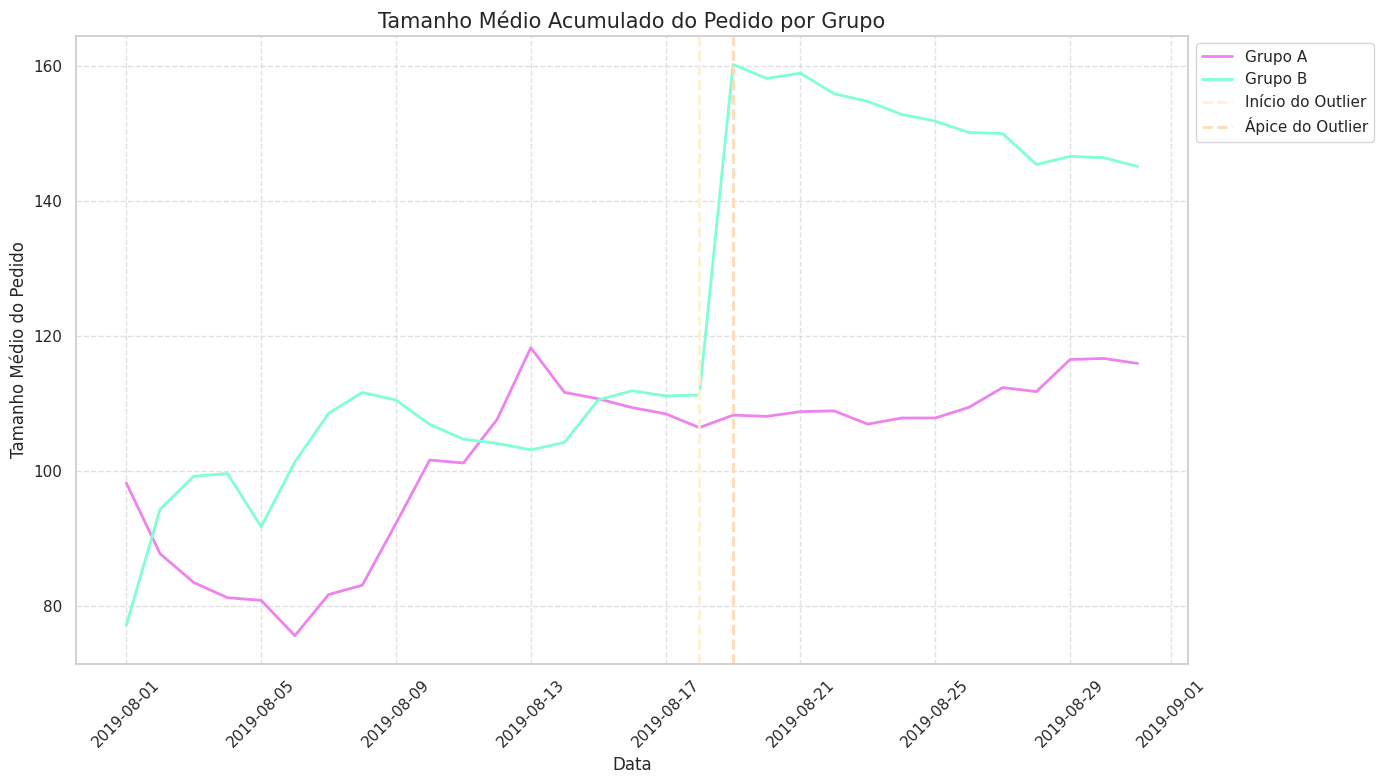

In [14]:
cumulativeRevenueA['average_order_size'] = cumulativeRevenueA['revenue'] / cumulativeRevenueA['transaction_id']
cumulativeRevenueB['average_order_size'] = cumulativeRevenueB['revenue'] / cumulativeRevenueB['transaction_id']

plt.figure(figsize=(14, 8))

plt.plot(
    cumulativeRevenueA['date'], 
    cumulativeRevenueA['average_order_size'], 
    label='Grupo A', 
    color='violet', 
    linewidth=2
)
plt.plot(
    cumulativeRevenueB['date'], 
    cumulativeRevenueB['average_order_size'], 
    label='Grupo B', 
    color='aquamarine', 
    linewidth=2
)

plt.axvline(
    x=pd.to_datetime('2019-08-18'), 
    color='papayawhip', 
    linestyle='--', 
    linewidth=2, 
    label='Início do Outlier'
)
plt.axvline(
    x=pd.to_datetime('2019-08-19'), 
    color='peachpuff', 
    linestyle='--', 
    linewidth=2, 
    label= 'Ápice do Outlier'
)

plt.title('Tamanho Médio Acumulado do Pedido por Grupo', fontsize=15)
plt.xlabel('Data')
plt.ylabel('Tamanho Médio do Pedido')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


O Grupo A, após algumas oscilações iniciais, parece estar se estabilizando em torno de um ticket médio de 115-120 no final do período. 

Já o Grupo B, apresenta evidência da presença dos *outliers*, a qual afeta diretamente o ticket médio. Esse evento distorceu completamente a média acumulada do grupo, elevando-a de aproximadamente 110 para 160 instantaneamente.

Observa-se que, após o salto, a linha do Grupo B começa a cair suavemente devido aos pedidos subsequentes que têm valores mais próximos do comportamento de compra esperado, diluindo lentamente o impacto daquele pedido atípico na média acumulada. Isso indica que o Grupo B ainda não se estabilizou em um patamar real.

Diante desse cenário, é impossível dizer se o Grupo B é realmente melhor que o Grupo A apenas por esta análise. 

### 3. Faça um gráfico da diferença relativa no tamanho médio acumulado do pedido para o grupo B em comparação com o grupo A.

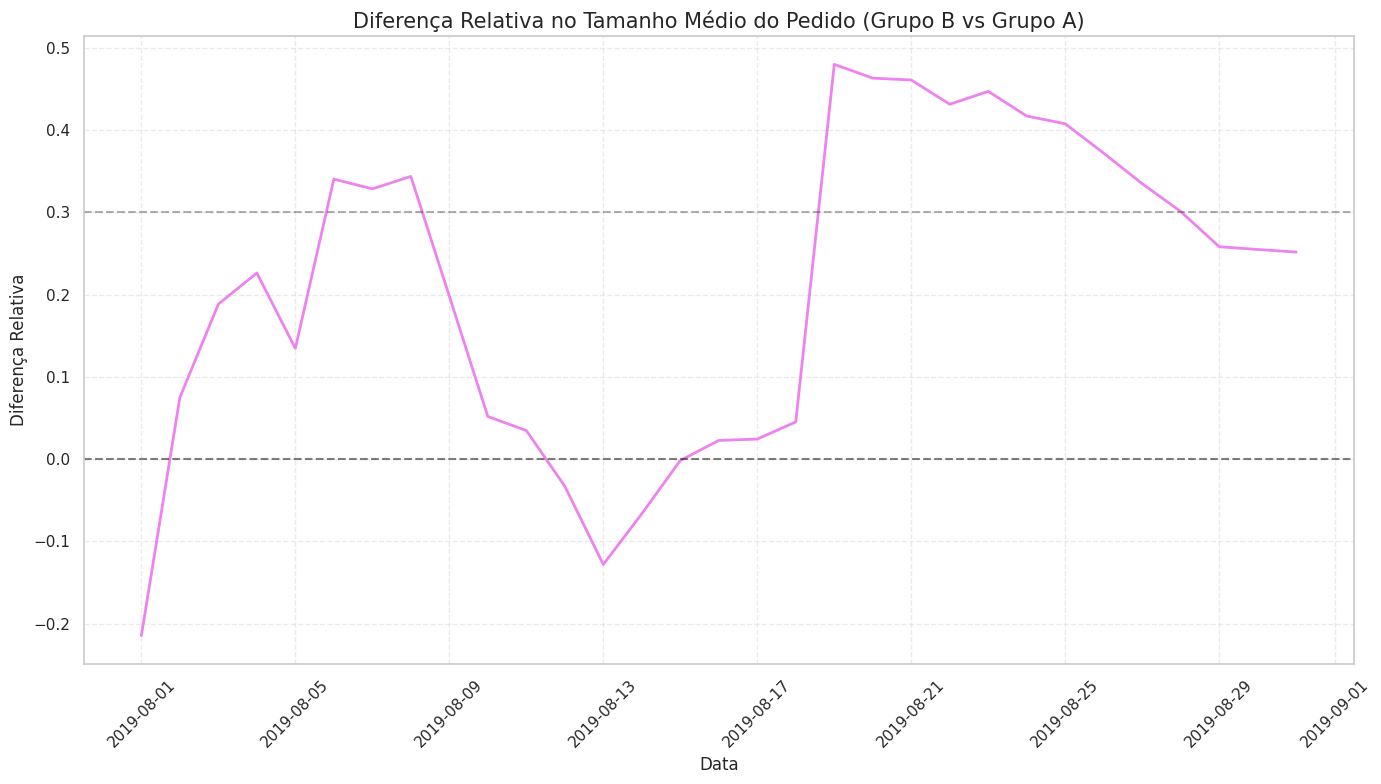

In [15]:
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB, 
    left_on='date', 
    right_on='date', 
    how='left', 
    suffixes=['A', 'B']
)

mergedCumulativeRevenue['relative_difference'] = (
    (
        mergedCumulativeRevenue['revenueB'] / mergedCumulativeRevenue['transaction_idB']
    ) / (
        mergedCumulativeRevenue['revenueA'] / mergedCumulativeRevenue['transaction_idA']
    ) - 1
)

plt.figure(figsize=(14, 8))

plt.plot(
    mergedCumulativeRevenue['date'], 
    mergedCumulativeRevenue['relative_difference'], 
    color='violet', 
    linewidth=2
)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0.3, color='black', linestyle='--', alpha=0.3) 

plt.title('Diferença Relativa no Tamanho Médio do Pedido (Grupo B vs Grupo A)', fontsize=15)
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Na primeira metade do mês (até o dia 17/08), a linha oscila drasticamente, começando negativa (Grupo A melhor), e sobe para uma vantagem de 30% para o Grupo B. Cai novamente e chega a ficar negativa por volta do dia 13/08, mostrando que os grupos não tinham uma diferença consolidada.

O ponto mais crítico é o salto vertical entre os dias 17/08 e 19/08, que gera vantagem para o Grupo B, disparando de quase 0% para quase 50% de superioridade em apenas dois dias, devido à presença dos *outliers* citados antes.
Após o pico de aproximadamente 48% no dia 19/08, a linha inicia uma descida constante. No final do período, a vantagem do Grupo B já caiu para cerca de 25%, diminuindo a influência dos atípicos.

Diante desses dados, nota-se que o teste ainda não estabilizou e se faz necessário continuar as análises para que a decisão não esteja baseada em anomalias.

### 4. Calcule a taxa de conversão de cada grupo como a proporção de pedidos para o número de visitas para cada dia.

In [16]:
visitsAggregated = datesGroups.apply(
    lambda x: visits[
        (visits['date'] <= x['date']) & (visits['group'] == x['group'])
    ].agg({
        'date': 'max', 
        'group': lambda g: g.iloc[0], 
        'visits': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

cumulativeData = ordersAggregated.merge(
    visitsAggregated, 
    left_on=['date', 'group'], 
    right_on=['date', 'group']
)
cumulativeData.columns = [
    'date', 
    'group', 
    'orders', 
    'buyers', 
    'revenue', 
    'visitors'
]

cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visitors']

cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']

print(cumulativeDataA.head(10))
print('----------------------')
print(cumulativeDataB.head(10))

         date group  orders  buyers  revenue  visitors  conversion
0  2019-08-01     A      24      20   2356.8       719    0.033380
2  2019-08-02     A      44      38   3860.3      1338    0.032885
4  2019-08-03     A      68      62   5675.5      1845    0.036856
6  2019-08-04     A      84      77   6822.1      2562    0.032787
8  2019-08-05     A     109     100   8810.2      3318    0.032851
10 2019-08-06     A     127     114   9600.0      3985    0.031870
12 2019-08-07     A     145     131  11842.9      4629    0.031324
14 2019-08-08     A     161     146  13373.3      5239    0.030731
16 2019-08-09     A     177     159  16320.4      5856    0.030225
18 2019-08-10     A     193     175  19608.6      6262    0.030821
----------------------
         date group  orders  buyers  revenue  visitors  conversion
1  2019-08-01     B      21      20   1620.0       713    0.029453
3  2019-08-02     B      45      43   4243.8      1294    0.034776
5  2019-08-03     B      61      59   6

- A taxa de conversão acumulada foi calculada diariamente para ambos os grupos. 
- Nos primeiros dias do teste, observou-se uma oscilação natural, com o Grupo A apresentando uma conversão ligeiramente superior no dia 01/08 (3,34% vs 2,95%).
- A partir de 06/08, o Grupo B assumiu a liderança de forma consistente, estabilizando sua vantagem competitiva e, ao final dos primeiros dez dias (10/08), o Grupo B já apresentava uma conversão de 3,63%, superando os 3,08% do Grupo A, o que indica uma tendência favorável à variante B em uma melhor conversão.

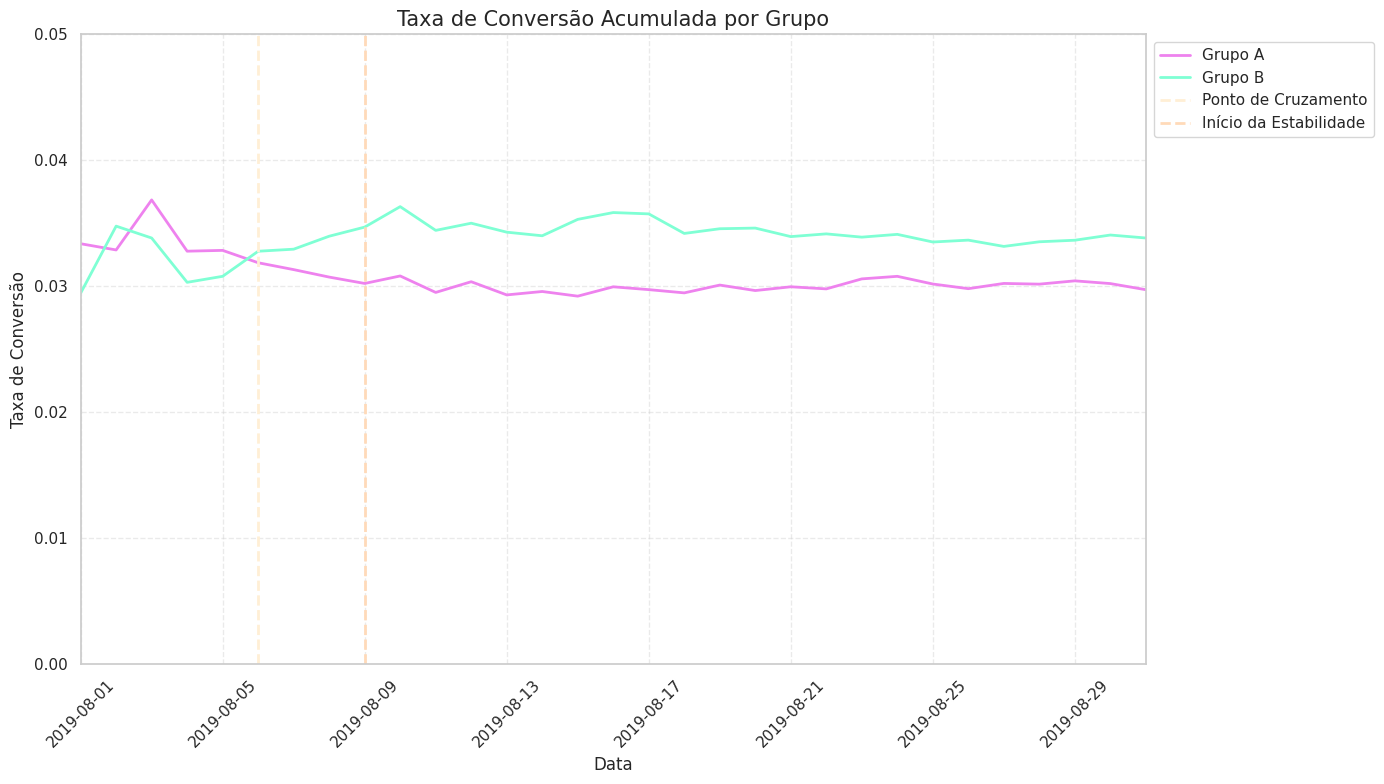

In [17]:
plt.figure(figsize=(14, 8))

plt.plot(
    cumulativeDataA['date'], 
    cumulativeDataA['conversion'], 
    label='Grupo A', 
    color='violet', 
    linewidth=2
)
plt.plot(
    cumulativeDataB['date'], 
    cumulativeDataB['conversion'], 
    label='Grupo B', 
    color='aquamarine', 
    linewidth=2
)

plt.axvline(
    x=pd.to_datetime('2019-08-06'), 
    color='papayawhip', 
    linestyle='--', 
    linewidth=2, 
    label='Ponto de Cruzamento'
)
plt.axvline(
    x=pd.to_datetime('2019-08-09'), 
    color='peachpuff', 
    linestyle='--', 
    linewidth=2, 
    label='Início da Estabilidade'
)

plt.title('Taxa de Conversão Acumulada por Grupo', fontsize=15)
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.axis([cumulativeData['date'].min(), cumulativeData['date'].max(), 0, 0.05]) 

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Diferente dos gráficos anteriores, as linhas de conversão mostram uma estabilização notável a partir do dia 09/0
8. As flutuações tornaram-se mínimas, indicando que os grupos atingiram um comportamento de compra consistente. A conversão do Grupo B estabilizou em torno de 3,4%, enquanto a do Grupo A ficou próxima de 3,0%.

O Grupo B assumiu a liderança de forma definitiva por volta do dia 06/08, como observado na tabela de conversão, e manteve-se consistentemente acima do Grupo A até o final do período. Além disso, a taxa de conversão não é afetada pelos *outliers* da receita. Isso prova que a vantagem do Grupo B na receita não é apenas por causa de uma anomalia, mas também porque ele realmente converte mais visitantes em compradores de forma orgânica e constante, atraindo uma proporção maior de clientes.

### 5. Faça um gráfico da diferença relativa na conversão cumulativa para o grupo B em comparação com o grupo A.

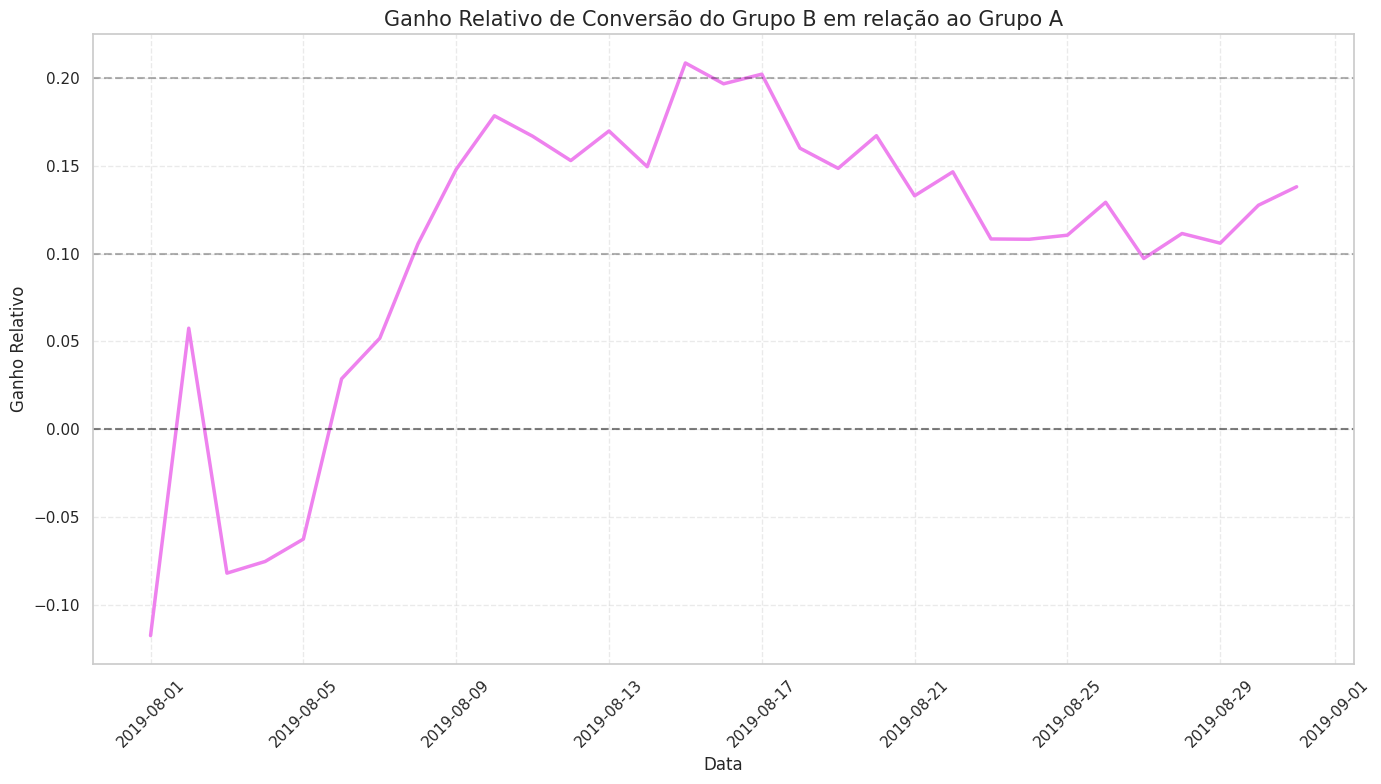

In [18]:
mergedCumulativeConversions = cumulativeDataA[
    ['date', 'conversion']
    ].merge(
    cumulativeDataB[['date', 'conversion']], 
        left_on='date', 
        right_on='date', 
        how='left', 
        suffixes=['A', 'B']
)

mergedCumulativeConversions['relative_gain'] = (
    mergedCumulativeConversions['conversionB'] / mergedCumulativeConversions['conversionA'] - 1
)

plt.figure(figsize=(14, 8))

plt.plot(
    mergedCumulativeConversions['date'], 
    mergedCumulativeConversions['relative_gain'], 
    color='violet', 
    linewidth=2.5
)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0.1, color='black', linestyle='--', alpha=0.3)
plt.axhline(y=0.2, color='black', linestyle='--', alpha=0.3)

plt.title('Ganho Relativo de Conversão do Grupo B em relação ao Grupo A', fontsize=15)
plt.xlabel('Data')
plt.ylabel('Ganho Relativo')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- O Grupo B assumiu a liderança definitiva em 06/08. A partir do dia 08/08, o ganho relativo ultrapassou a marca de 10% e nunca mais retornou ao patamar de igualdade ou inferioridade.
- A vantagem do Grupo B passou a oscilar consistentemente entre 10% e 20%. Esse intervalo é um forte indicativo de que a variante B é substancialmente superior em converter visitantes.
- O ganho relativo parece estar se estabilizando, por fim, em torno de 13% a 14%.

Diferente dos gráficos de receita, que ainda sofrem com a "descida" dos outliers, o gráfico de conversão já mostra uma maturidade muito maior, sugerindo que o resultado é confiável. Isso valida que as mudanças implementadas na variante B são eficazes e escaláveis.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- [x] A receita cumulativa por grupo foi analisada
- [x] A diferença relativa do tamanho médio do pedido foi calculada
- [x] A conversão por grupo foi analisada

</div>

### 6. Calcule os percentis 95 e 99 para o número de pedidos por usuário.

In [19]:
ordersByUsers = (
    orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)
ordersByUsers.columns = ['visitor_id', 'orders']
percentiles = np.percentile(ordersByUsers['orders'], [95, 99])

print(f"Percentil 95: {percentiles[0]} pedidos por usuário")
print(f"Percentil 99: {percentiles[1]} pedidos por usuário")


Percentil 95: 2.0 pedidos por usuário
Percentil 99: 4.0 pedidos por usuário


- Define-se como anomalias os usuários que realizaram mais de 2 pedidos, ou seja, 5% dos usuários.
- O 99% indica que apenas 1% dos usuários fizeram mais de 4 pedidos.

Determina-se, portanto, que a escolha de 95% é mais estratégica para este teste, pois permite filtrar os 5% de usuários com comportamento atípico, garantindo que a análise de conversão reflita o comportamento da grande maioria da base de clientes e não seja distorcida por um pequeno grupo de supercompradores.

### 7. Faça um gráfico de dispersão dos preços dos pedidos.

In [20]:
print(orders.sort_values(by='revenue',ascending=False).head(10))

      transaction_id  visitor_id       date  revenue group
425        590470918  1920142716 2019-08-19  19920.4     B
1196      3936777065  2108080724 2019-08-15   3120.1     B
858        192721366  1316129916 2019-08-27   1450.2     A
1136       666610489  1307669133 2019-08-13   1425.8     A
744       3668308183   888512513 2019-08-27   1335.6     B
662       1811671147  4266935830 2019-08-29   1220.2     A
682       1216533772  4266935830 2019-08-29   1220.2     B
743       3603576309  4133034833 2019-08-09   1050.0     A
1103      1348774318  1164614297 2019-08-12   1025.8     A
1099       316924019   148427295 2019-08-12   1015.9     A


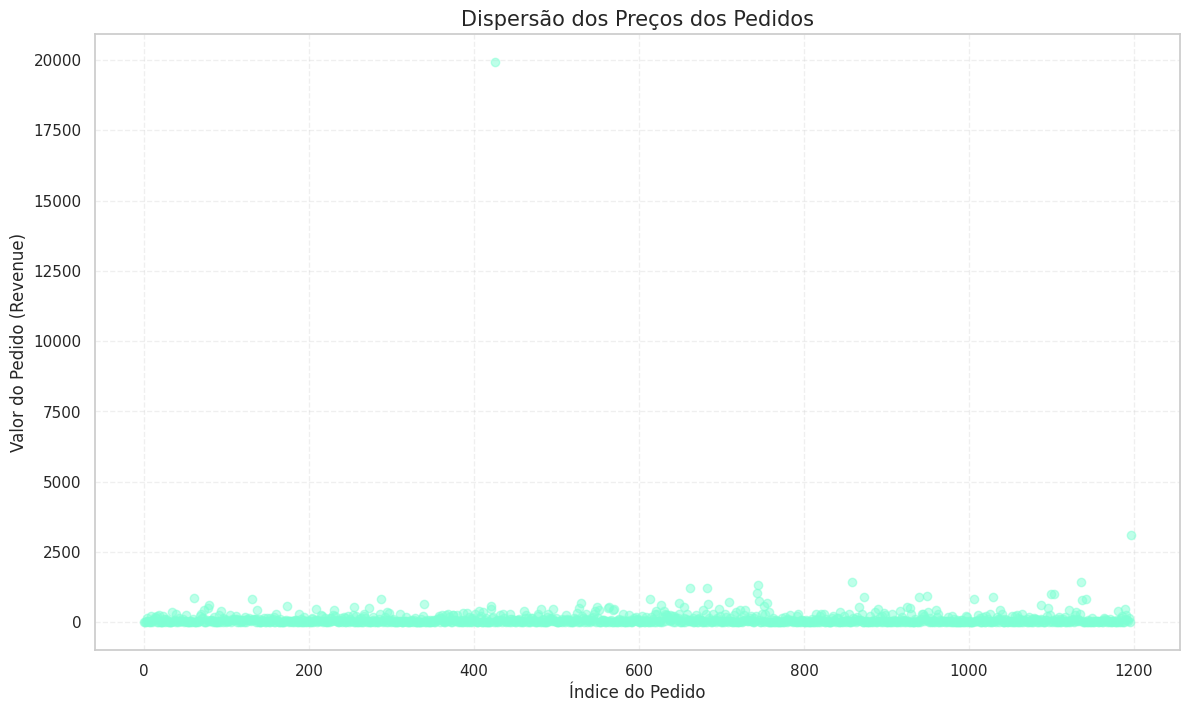

In [21]:
plt.figure(figsize=(14, 8))

x_values = pd.Series(range(0, len(orders['revenue'])))

plt.scatter(
    x_values, 
    orders['revenue'], 
    color='aquamarine', 
    alpha=0.5
)

plt.title('Dispersão dos Preços dos Pedidos', fontsize=15)
plt.xlabel('Índice do Pedido')
plt.ylabel('Valor do Pedido (Revenue)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

- Foram identificados os pedidos *ouliers* do Grupo B a partir do gráfico. O maior valor foi de 19.920,40, sendo 13x maior que o limite superior da concentração. O segundo teve o valor de 3.120,10, que ainda está bem acima da média, um pouco a mais que o dobro da concentração, e contribui para inflar os resultados desse grupo.
- A massa de dados está abaixo de 1.500. Nota-se que os maiores pedidos do Grupo A (como os de 1.450,20 e 1.425,80) estão dentro dessa faixa de "normalidade alta", enquanto o Grupo B foi "presenteado" com dois valores atípicos.

### 8. Calcule os percentis 95 e 99 dos preços dos pedidos.

In [22]:
percentiles_revenue = np.percentile(orders['revenue'], [95, 99])

print(f"Percentil 95: {percentiles_revenue[0]:.2f}")
print(f"Percentil 99: {percentiles_revenue[1]:.2f}")

Percentil 95: 435.54
Percentil 99: 900.90


- Os 95% dos pedidos são menores que 435,54. e apenas 1% dos pedidos são maiores que 900,90.
- Por mais que a nuvem de concentração se estenda até quase 1.500, os percentuais revelam que a normalidade dos valores é ainda mais baixa.

Define-se, diante desse retorno, o valor dos 1% como ponto de corte para *outliers* da receita, removendo os valores que distorcem as médias, sem descartar um volume excessivo de dados.

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Os percentis 95 e 99 foram calculados para o número de pedidos e preços. Sugestão: faça o cálculo por grupo também.
</div>

### 9. Encontre a significância estatística da diferença na conversão entre os grupos usando os dados brutos.

In [23]:
ordersByUsersA = (
    orders[orders['group'] == 'A']
        .groupby('visitor_id', as_index=False)
        .agg({'transaction_id': 'nunique'})
)
ordersByUsersA.columns = ['visitor_id', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
        .groupby('visitor_id', as_index=False)
        .agg({'transaction_id': 'nunique'})
)
ordersByUsersB.columns = ['visitor_id', 'orders']

sampleA = pd.concat(
    [
        ordersByUsersA['orders'],
        pd.Series(
            0, 
            index=np.arange(
                visits[visits['group'] == 'A']['visits'].sum() 
                - len(ordersByUsersA['orders'])
            ), name='orders'
        )
    ], axis=0
)

sampleB = pd.concat(
    [
        ordersByUsersB['orders'],
        pd.Series(
            0, 
            index=np.arange(
                visits[visits['group'] == 'B']['visits'].sum() 
                - len(ordersByUsersB['orders'])
            ), name='orders'
        )
    ], axis=0
)

p_value = stats.mannwhitneyu(sampleA, sampleB)[1]
relative_gain = sampleB.mean() / sampleA.mean() - 1

print(f"P-value: {p_value:.3f}")
print(f"Ganho relativo do Grupo B: {relative_gain:.2%}")


P-value: 0.017
Ganho relativo do Grupo B: 13.81%


- O P-value de 0.017 é menor que o nível de significância padrão de 0.05 (5%), ou seja, a probabilidade dessa diferença ter ocorrido por puro acaso é de apenas 1,7%. Portanto, rejeita-se a hipótese nula, afirmando que existe uma diferença estatisticamente significante na conversão entre os grupos.
- O ganho relativo de 13,81% do Grupo B sobre o Grupo A é um resultado expressivo, confirmando que a variante B é superior na conversão de visitantes em compradores.

**Obs.:** Esse valor de 13,81% está perfeitamente alinhado com o que foi observado no gráfico de diferença relativa da taxa de conversão, onde a linha se estabilizou justamente entre 13% e 14%.

### 10. Encontre a significância estatística da diferença no tamanho médio do pedido entre os grupos usando os dados brutos.

In [24]:
revenueA = orders[orders['group'] == 'A']['revenue']
revenueB = orders[orders['group'] == 'B']['revenue']

p_value_revenue = stats.mannwhitneyu(revenueA, revenueB)[1]
relative_gain_revenue = revenueB.mean() / revenueA.mean() - 1

print(f"P-value (Ticket Médio): {p_value_revenue:.3f}")
print(f"Diferença relativa do Grupo B: {relative_gain_revenue:.2%}")

P-value (Ticket Médio): 0.692
Diferença relativa do Grupo B: 25.17%


- O P-value de 0.692 é expressivamente superior ao nível de 0.05, indicando que não há diferença estatisticamente significante no tamanho médio do pedido entre os grupos, apesar da diferença visual observada.
- A diferença relativa de 25,17% a favor do Grupo B é uma distorção causada pela presença dos *outliers* identificados anteriormente.

Entende-se que, embora o Grupo B gere mais receita total, isso se deve ao maior volume de conversões e a eventos atípicos de alto valor, e não a um aumento real e generalizado no ticket médio dos usuários.

### 11. Encontre a significância estatística da diferença na conversão entre os grupos usando os dados filtrados.

In [25]:
usersWithManyOrders = ordersByUsers[ordersByUsers['orders'] > 2]['visitor_id']
usersWithExpensiveOrders = orders[orders['revenue'] > 900.90]['visitor_id']

abnormalUsers = pd.concat(
    [
        usersWithManyOrders, 
        usersWithExpensiveOrders
    ], axis=0
).drop_duplicates().sort_values()

print(f"Total de usuários anômalos identificados: {len(abnormalUsers)}")


Total de usuários anômalos identificados: 41


In [26]:
orders_filtered = orders[~orders['visitor_id'].isin(abnormalUsers)]

ordersByUsersA_filtered = (
    orders_filtered[orders_filtered['group'] == 'A']
        .groupby('visitor_id', as_index=False)
        .agg({'transaction_id': 'nunique'})
)
ordersByUsersA_filtered.columns = ['visitor_id', 'orders']

ordersByUsersB_filtered = (
    orders_filtered[orders_filtered['group'] == 'B']
        .groupby('visitor_id', as_index=False)
        .agg({'transaction_id': 'nunique'})
)
ordersByUsersB_filtered.columns = ['visitor_id', 'orders']

sampleA_filtered = pd.concat(
    [
        ordersByUsersA_filtered['orders'],
        pd.Series(
            0, 
            index=np.arange(
                visits[visits['group'] == 'A']['visits'].sum() 
                - len(ordersByUsersA_filtered['orders'])
            ), name='orders'
        )
    ], axis=0
)

sampleB_filtered = pd.concat(
    [
        ordersByUsersB_filtered['orders'],
        pd.Series(
            0, 
            index=np.arange(
                visits[visits['group'] == 'B']['visits'].sum() 
                - len(ordersByUsersB_filtered['orders'])
            ), name='orders'
        )
    ], axis=0
)

p_value_filtered = stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]
relative_gain_filtered = sampleB_filtered.mean() / sampleA_filtered.mean() - 1

print(f"P-value (Conversão Filtrada): {p_value_filtered:.3f}")
print(f"Ganho relativo do Grupo B (Filtrado): {relative_gain_filtered:.2%}")

P-value (Conversão Filtrada): 0.009
Ganho relativo do Grupo B (Filtrado): 17.58%


- Após remover 41 usuários anômalos, aqueles que fizeram ou mais de 2 compras ou compras de valor acima de 900.90, o P-value reduziu para 0.009. Essa redução reforça a significância estatística da diferença entre os grupos (p < 0.01).
- O ganho relativo do Grupo B subiu para 17,58%, mantendo a evidência de que a variante B é substancialmente mais eficaz em converter os usuários.

A limpeza dos dados confirmou que a superioridade do Grupo B é orgânica e não depende de comportamentos atípicos, validando a implementação da mudança testada.

### 12. Encontre a significância estatística da diferença no tamanho médio do pedido entre os grupos usando os dados filtrados.

In [27]:
revenueA_filtered = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenueB_filtered = orders_filtered[orders_filtered['group'] == 'B']['revenue']

p_value_revenue_filtered = stats.mannwhitneyu(revenueA_filtered, revenueB_filtered)[1]
relative_gain_revenue_filtered = revenueB_filtered.mean() / revenueA_filtered.mean() - 1

print(f"P-value (Ticket Médio Filtrado): {p_value_revenue_filtered:.3f}")
print(f"Diferença relativa do Grupo B (Filtrado): {relative_gain_revenue_filtered:.2%}")


P-value (Ticket Médio Filtrado): 0.857
Diferença relativa do Grupo B (Filtrado): -2.31%


- O P-value de 0,857 confirma que não há diferença estatisticamente significante no tamanho médio do pedido entre os grupos após a remoção das anomalias.
- A diferença relativa do Grupo B caiu para -2,31%, o que demonstra que a vantagem anterior de 25% era puramente artificial, causada pelos *outliers* de alto valor.

Entende-se que a variante B é superior apenas na taxa de conversão, mantendo um ticket médio equivalente ao da variante A. Portanto, o aumento na receita total do Grupo B é impulsionado pelo maior volume de compradores, e não por um aumento no valor gasto por transação.

### 13. Tome uma decisão com base nos resultados do teste. As decisões possíveis são:
1. Pare o teste, considere um dos grupos o líder.
2. Pare o teste, conclua que não há diferença entre os grupos.
3. Continue o teste.

Diante das análises e retornos, sugere-se interromper o teste e declarar o Grupo B como vencedor diante das conjecturas e conclusões apresentadas anteriormente.

# Conclusão

O presente projeto teve como objetivo realizar a análise e priorização de hipóteses, a elaboração de teste A/B e a identificação da melhor estratégia de continuidade. O trabalho foi segmentado em três etapas: tratamento de dados, priorização de hipóteses e realização do teste A/B. 

Na primeira fase, aplicou-se uma estruturação rigorosa nas bases de dados com padronização *snake_case* e formatação temporal. Na sequência, utilizaram-se os frameworks **ICE** e **RICE**, identificando que a inclusão do fator Alcance (Reach) alterava drasticamente a ordem estratégica, direcionando o foco para iniciativas com maior potencial de escala. Na análise do teste A/B, observou-se uma liderança expressiva do Grupo B na receita acumulada e no ticket médio, porém evidenciou-se que este salto era impulsionado por *outliers* extremos (pedidos de até 19.920,40). Em contrapartida, a taxa de conversão acumulada mostrou uma estabilização muito mais sólida e orgânica a partir de 09/08, com o Grupo B mantendo-se consistentemente acima do Grupo A, sugerindo que a variante B era superior em transformar visitantes em compradores, independentemente do valor gasto.

Para validar esta hipótese, aplicou-se o teste estatístico de **Mann-Whitney**, que confirmou uma diferença significante na conversão (P-value 0,017) e a ausência de significância no ticket médio (P-value 0,692) nos dados brutos. Ao refinar a análise removendo 41 usuários anômalos (com base nos percentis 95 e 99), a significância da conversão tornou-se ainda mais robusta (P-value 0,009), com um ganho relativo de 17,58% para o Grupo B, enquanto a diferença no ticket médio praticamente desapareceu (-2,31%).

Conclui-se que a variante B é a vencedora do teste, pois gera um aumento real e sustentável no volume de conversões sem depender de anomalias de receita. Portanto, recomenda-se a interrupção do teste e a implementação definitiva das mudanças testadas no Grupo B, garantindo uma operação de marketing mais eficiente e com maior capacidade de conversão orgânica da base de usuários.

</div><div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os testes de hipóteses foram conduzidos corretamente
- O `p-value` foi apresentado
- As conclusões foram apresentadas
</div>